HW_3: Win Probability

In [40]:
import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import tabulate
from nflreadpy import load_pbp
import pyarrow
import sportsdataverse as sdv
import polars as pl
from great_tables import GT, md
from adjustText import adjust_text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss

In [41]:
# Set seed for reproducibility
np.random.seed(42)

In [42]:
seasons = range(2021, 2026)
weeks = range(1, 19)
raw_stats_list = []

# ---------------------------------------------------------
# Data Ingestion Loop
# ---------------------------------------------------------

for yr in seasons:
    try:
        # NFL season 
        pbp = nfl.load_pbp([yr])

        for wk in weeks:

            data = pbp.filter(
                (pbp["week"] == wk) &
                (pbp["season_type"] == "REG")
            )

            for game_id in data["game_id"].unique().to_list():

                game = data.filter(
                    data["game_id"] == game_id
                )

                # Get the teams from the game
                home_team = game["home_team"][0]
                away_team = game["away_team"][0]

                # Get final score
                home_points = game["home_score"].max()
                away_points = game["away_score"].max()

                # Helper to extract metric by name
                def get_stat(team_data, team, stat_name):

                    team_plays = team_data.filter(
                        team_data["posteam"] == team
                    )

                    if stat_name == "totalYards":
                        return team_plays["yards_gained"].sum()

                    if stat_name == "passingYards":
                        return team_plays["passing_yards"].sum()

                    if stat_name == "rushingYards":
                        return team_plays["rushing_yards"].sum()

                    if stat_name == "turnovers":
                        interceptions = team_plays["interception"].sum()
                        fumbles = team_plays["fumble_lost"].sum()
                        return (
                            (interceptions or 0) +
                            (fumbles or 0)
                        )
                    if stat_name == "firstDowns":
                        return team_plays["first_down"].sum()

                    if stat_name == "thirdDownEff":
                        converted = team_plays[
                            "third_down_converted"
                        ].sum()
                        failed = team_plays[
                            "third_down_failed"
                        ].sum()
                        attempts = (
                            (converted or 0) +
                            (failed or 0)
                        )
                        if attempts == 0:
                            return None

                        return f"{converted}-{attempts}"

                    if stat_name == "penaltyYards":
                        return team_plays["penalty_yards"].sum()

                    return None
                    
                # Create a row for each team
                for idx, team in enumerate(
                    [home_team, away_team]
                ):
                    # Find opponent
                    opp_data = (
                        away_team
                        if team == home_team
                        else home_team
                    )
                    # Home or away
                    home_away = (
                        "home"
                        if team == home_team
                        else "away"
                    )
                    # Points
                    points = (
                        home_points
                        if team == home_team
                        else away_points
                    )
                    points_allowed = (
                        away_points
                        if team == home_team
                        else home_points
                    )

                    row = {
                        "game_id": game_id,
                        "season": str(yr),
                        "week_num": wk,
                        "team": team,
                        "opponent": opp_data,
                        "home_away": home_away,
                        "points": points,
                        "points_allowed": points_allowed,
                        "total_yards":
                            get_stat(
                                game,
                                team,
                                "totalYards"
                            ),
                        "total_yards_allowed":
                            get_stat(
                                game,
                                opp_data,
                                "totalYards"
                            ),
                        "passing_yards":
                            get_stat(
                                game,
                                team,
                                "passingYards"
                            ),
                        "passing_yards_allowed":
                            get_stat(
                                game,
                                opp_data,
                                "passingYards"
                            ),
                        "rushing_yards":
                            get_stat(
                                game,
                                team,
                                "rushingYards"
                            ),
                        "rushing_yards_allowed":
                            get_stat(
                                game,
                                opp_data,
                                "rushingYards"
                            ),
                        "turnovers":
                            get_stat(
                                game,
                                team,
                                "turnovers"
                            ),
                        "turnovers_allowed":
                            get_stat(
                                game,
                                opp_data,
                                "turnovers"
                            ),
                        "first_downs":
                            get_stat(
                                game,
                                team,
                                "firstDowns"
                            ),
                        "first_downs_allowed":
                            get_stat(
                                game,
                                opp_data,
                                "firstDowns"
                            ),
                        "third_down_eff":
                            get_stat(
                                game,
                                team,
                                "thirdDownEff"
                            ),
                        "third_down_eff_allowed":
                            get_stat(
                                game,
                                opp_data,
                                "thirdDownEff"
                            ),
                        "total_penalties_yards":
                            get_stat(
                                game,
                                team,
                                "penaltyYards"
                            ),
                        "total_penalties_yards_allowed":
                            get_stat(
                                game,
                                opp_data,
                                "penaltyYards"
                            )
                    }
                    raw_stats_list.append(row)

    except Exception as e:
        print(f"Error loading {yr}: {e}")
        continue

raw_team_stats = pd.DataFrame(raw_stats_list)

print(raw_team_stats.shape)
raw_team_stats.head()

(2718, 22)


,game_id,season,week_num,team,opponent,home_away,points,points_allowed,total_yards,total_yards_allowed,...,rushing_yards,rushing_yards_allowed,turnovers,turnovers_allowed,first_downs,first_downs_allowed,third_down_eff,third_down_eff_allowed,total_penalties_yards,total_penalties_yards_allowed
0,2021_01_PHI_ATL,2021,1,ATL,PHI,home,6,32,260.0,436.0,...,124.0,173.0,0.0,0.0,18.0,23.0,3.0-14.0,6.0-13.0,112.0,76.0
1,2021_01_PHI_ATL,2021,1,PHI,ATL,away,32,6,436.0,260.0,...,173.0,124.0,0.0,0.0,23.0,18.0,6.0-13.0,3.0-14.0,76.0,112.0
2,2021_01_JAX_HOU,2021,1,HOU,JAX,home,37,21,449.0,395.0,...,160.0,76.0,0.0,3.0,21.0,19.0,12.0-21.0,3.0-11.0,47.0,85.0
3,2021_01_JAX_HOU,2021,1,JAX,HOU,away,21,37,395.0,449.0,...,76.0,160.0,3.0,0.0,19.0,21.0,3.0-11.0,12.0-21.0,85.0,47.0
4,2021_01_BAL_LV,2021,1,LV,BAL,home,33,27,491.0,406.0,...,82.0,189.0,1.0,2.0,26.0,20.0,7.0-15.0,3.0-12.0,113.0,20.0


In [43]:
# ---------------------------------------------------------
# Model 1: Game-Level Differentials
# ---------------------------------------------------------

def parse_time_sec(time_str):
    if pd.isna(time_str):
        return 0.0
    parts = str(time_str).split(":")
    
    if len(parts) == 2:
        try:
            return float(parts[0]) * 60 + float(parts[1])
        except ValueError:
            return 0.0 
    return 0.0

def parse_split_eff(eff_str, pos=0):
    if pd.isna(eff_str):
        return 0.0
    
    parts = str(eff_str).split("-")
    
    if len(parts) == 2:
        try:
            return float(parts[pos])
        except ValueError:
            return 0.0
    return 0.0


In [44]:
df = raw_team_stats.copy()

# Remove games without a final score or ties
df = df.dropna(subset=["points", "points_allowed"])
df = df[df["points"] != df["points_allowed"]]

# Convert scores to numbers
df["points"] = pd.to_numeric(
    df["points"], errors="coerce"
)

df["points_allowed"] = pd.to_numeric(
    df["points_allowed"], errors="coerce"
)

# Win 
df["win"] = (
    df["points"] > df["points_allowed"]
).astype(int)

# Third-down 
df["td_comp"] = df["third_down_eff"].apply(
    lambda x: parse_split_eff(x, 0)
)

df["td_att"] = df["third_down_eff"].apply(
    lambda x: parse_split_eff(x, 1)
)

df["td_comp_opp"] = df["third_down_eff_allowed"].apply(
    lambda x: parse_split_eff(x, 0)
)

df["td_att_opp"] = df["third_down_eff_allowed"].apply(
    lambda x: parse_split_eff(x, 1)
)

# Penalty yards
df["pen_yds"] = pd.to_numeric(
    df["total_penalties_yards"], errors="coerce"
).fillna(0.0)

df["pen_yds_opp"] = pd.to_numeric(
    df["total_penalties_yards_allowed"], errors="coerce"
).fillna(0.0)

# Third-down percentage
df["third_down_pct"] = np.where(
    df["td_att"] > 0,
    df["td_comp"] / df["td_att"],
    0.0
)

df["third_down_pct_opp"] = np.where(
    df["td_att_opp"] > 0,
    df["td_comp_opp"] / df["td_att_opp"],
    0.0
)

# Convert numeric NFL statistics
num_cols = [
    "turnovers",
    "turnovers_allowed",
    "passing_yards",
    "passing_yards_allowed",
    "rushing_yards",
    "rushing_yards_allowed",
    "first_downs",
    "first_downs_allowed"
]

for col in num_cols:
    df[col] = pd.to_numeric(
        df[col], errors="coerce"
    ).fillna(0.0)

In [45]:
# Computing differentials
df["turnover_margin"] = df["turnovers_allowed"] - df["turnovers"]
df["pass_yards_diff"] = (
    df["passing_yards"] - df["passing_yards_allowed"]
)
df["rush_yards_diff"] = (
    df["rushing_yards"] - df["rushing_yards_allowed"]
)
df["first_downs_diff"] = (
    df["first_downs"] - df["first_downs_allowed"]
)
df["third_down_pct_diff"] = (
    df["third_down_pct"] - df["third_down_pct_opp"]
)
df["penalty_yards_diff"] = (
    df["pen_yds"] - df["pen_yds_opp"]
)
df["is_home"] = (
    df["home_away"].str.lower() == "home"
).astype(int)
diff_predictors = [
    "is_home",
    "turnover_margin",
    "pass_yards_diff",
    "rush_yards_diff",
    "first_downs_diff",
    "third_down_pct_diff",
    "penalty_yards_diff"
]
df = df.dropna(
    subset=["win"] + diff_predictors
)

df.head()

,game_id,season,week_num,team,opponent,home_away,points,points_allowed,total_yards,total_yards_allowed,...,pen_yds_opp,third_down_pct,third_down_pct_opp,turnover_margin,pass_yards_diff,rush_yards_diff,first_downs_diff,third_down_pct_diff,penalty_yards_diff,is_home
0,2021_01_PHI_ATL,2021,1,ATL,PHI,home,6,32,260.0,436.0,...,76.0,0.214286,0.461538,0.0,-100.0,-49.0,-5.0,-0.247253,36.0,1
1,2021_01_PHI_ATL,2021,1,PHI,ATL,away,32,6,436.0,260.0,...,112.0,0.461538,0.214286,0.0,100.0,49.0,5.0,0.247253,-36.0,0
2,2021_01_JAX_HOU,2021,1,HOU,JAX,home,37,21,449.0,395.0,...,85.0,0.571429,0.272727,3.0,-41.0,84.0,2.0,0.298701,-38.0,1
3,2021_01_JAX_HOU,2021,1,JAX,HOU,away,21,37,395.0,449.0,...,47.0,0.272727,0.571429,-3.0,41.0,-84.0,-2.0,-0.298701,38.0,0
4,2021_01_BAL_LV,2021,1,LV,BAL,home,33,27,491.0,406.0,...,20.0,0.466667,0.250000,1.0,200.0,-107.0,6.0,0.216667,93.0,1


In [46]:
X_diff = df[diff_predictors]
y_diff = df["win"]
strata_diff = df["season"]

X_train, X_test, y_train, y_test = train_test_split(
    X_diff,
    y_diff,
    test_size=0.20,
    random_state=2026,
    stratify=strata_diff
)

test_indices = X_test.index
test_seasons = df.loc[test_indices, "season"]

# Standardizing features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=diff_predictors,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=diff_predictors,
    index=X_test.index
)
# Add constant for statsmodels Logit
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)

In [47]:
# Fit Logistic Regression Model
logit_model_diff = sm.Logit(y_train, X_train_sm).fit(disp=False)

# Feature Importance Summary Table
summary_df = pd.DataFrame({
    "Predictor": logit_model_diff.params.index,
    "Std Beta": logit_model_diff.params.values,
    "Odds Ratio (1 SD)": np.exp(logit_model_diff.params.values),
    "z-statistic": logit_model_diff.tvalues.values,
    "p-value": logit_model_diff.pvalues.values
})
summary_df = summary_df[
    summary_df["Predictor"] != "const"
].copy()
summary_df["Importance (|z|)"] = (
    summary_df["z-statistic"].abs()
)
summary_df = summary_df.sort_values(
    by="Importance (|z|)",
    ascending=False
)
print(summary_df.to_string(index=False))

          Predictor  Std Beta  Odds Ratio (1 SD)  z-statistic      p-value  Importance (|z|)
    turnover_margin  1.777560           5.915407    19.815072 2.206934e-87         19.815072
third_down_pct_diff  0.774217           2.168892     9.467215 2.874030e-21          9.467215
    rush_yards_diff  0.859402           2.361747     8.367245 5.898110e-17          8.367245
    pass_yards_diff  0.595524           1.813982     6.022713 1.715179e-09          6.022713
 penalty_yards_diff -0.259247           0.771632    -4.106199 4.022222e-05          4.106199
   first_downs_diff  0.437063           1.548154     3.586679 3.349166e-04          3.586679
            is_home  0.061431           1.063358     0.983369 3.254258e-01          0.983369


C:\Users\jordy\AppData\Local\Temp\ipykernel_32300\1430516408.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Importance (|z|)", y="Predictor", palette="mako")


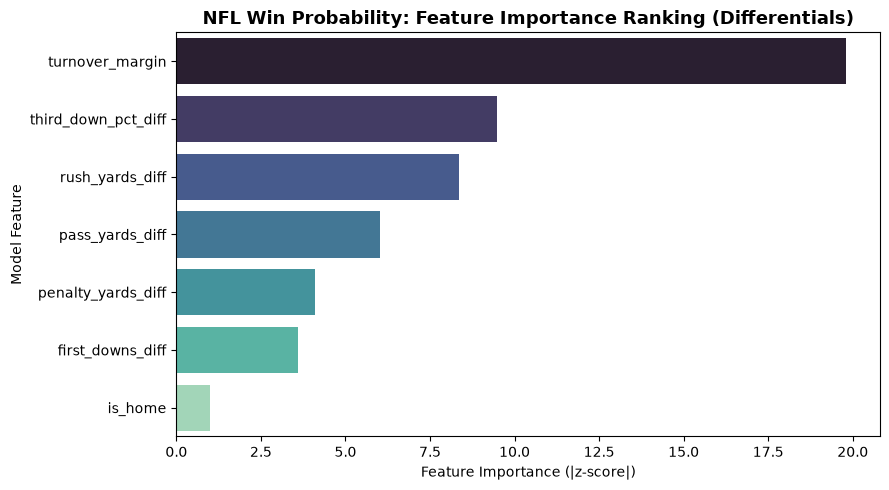

In [48]:
# Plot Feature Importance
plt.figure(figsize=(9, 5))
sns.barplot(data=summary_df, x="Importance (|z|)", y="Predictor", palette="mako")
plt.title("NFL Win Probability: Feature Importance Ranking (Differentials)", fontsize=13, fontweight="bold")
plt.xlabel("Feature Importance (|z-score|)")
plt.ylabel("Model Feature")
plt.tight_layout()
plt.show()

Out-of-Sample Performance & Calibration Plots (Differentials)

In [49]:


pred_probs_diff = logit_model_diff.predict(X_test_sm)
pred_class_diff = (pred_probs_diff >= 0.5).astype(int)

metrics_diff = pd.DataFrame({
    "Metric": ["Accuracy", "ROC AUC", "Log Loss", "Brier Score"],
    "Test Score": [
        accuracy_score(y_test, pred_class_diff),
        roc_auc_score(y_test, pred_probs_diff),
        log_loss(y_test, pred_probs_diff),
        brier_score_loss(y_test, pred_probs_diff)
    ]
})

print("Out-of-Sample Performance (Differentials Model):")
print(metrics_diff.to_string(index=False))

Out-of-Sample Performance (Differentials Model):
     Metric  Test Score
   Accuracy    0.815498
    ROC AUC    0.892049
   Log Loss    0.417320
Brier Score    0.134580


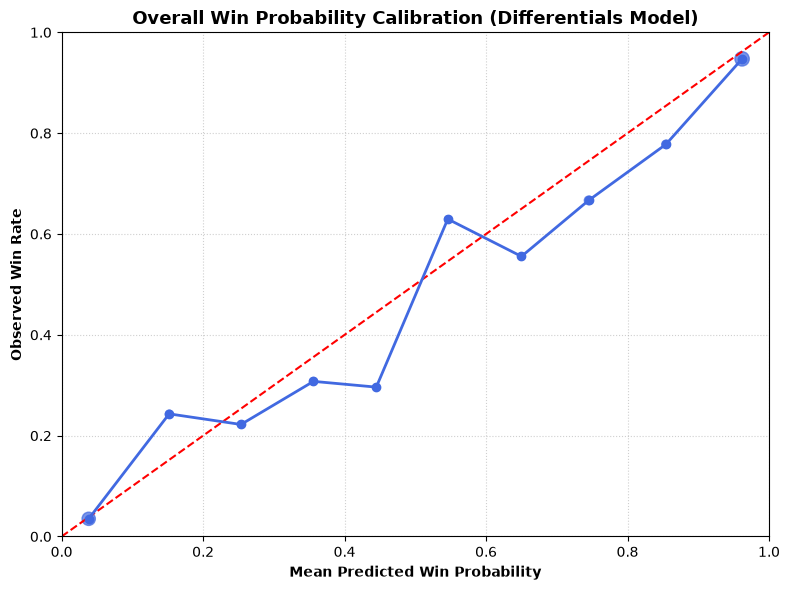

In [50]:
# Function for aggregate calibration plot
def plot_overall_calibration(y_true, y_probs, title_suffix=""):
    df_cal = pd.DataFrame({"actual": y_true, "pred": y_probs})
    df_cal["prob_bin"] = pd.cut(df_cal["pred"], bins=np.linspace(0, 1, 11), include_lowest=True)
    
    agg = df_cal.groupby("prob_bin", observed=False).agg(
        mean_pred=("pred", "mean"),
        actual_win_rate=("actual", "mean"),
        game_count=("actual", "count")
    ).reset_index().dropna()

    plt.figure(figsize=(8, 6))
    plt.plot([0, 1], [0, 1], "r--", linewidth=1.5, label="Perfect Calibration")
    plt.plot(agg["mean_pred"], agg["actual_win_rate"], "o-", color="royalblue", linewidth=2)
    plt.scatter(agg["mean_pred"], agg["actual_win_rate"], s=agg["game_count"] * 0.8, color="royalblue", alpha=0.7)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("Mean Predicted Win Probability", fontweight="bold")
    plt.ylabel("Observed Win Rate", fontweight="bold")
    plt.title(f"Overall Win Probability Calibration {title_suffix}", fontsize=13, fontweight="bold")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_overall_calibration(y_test, pred_probs_diff, "(Differentials Model)")

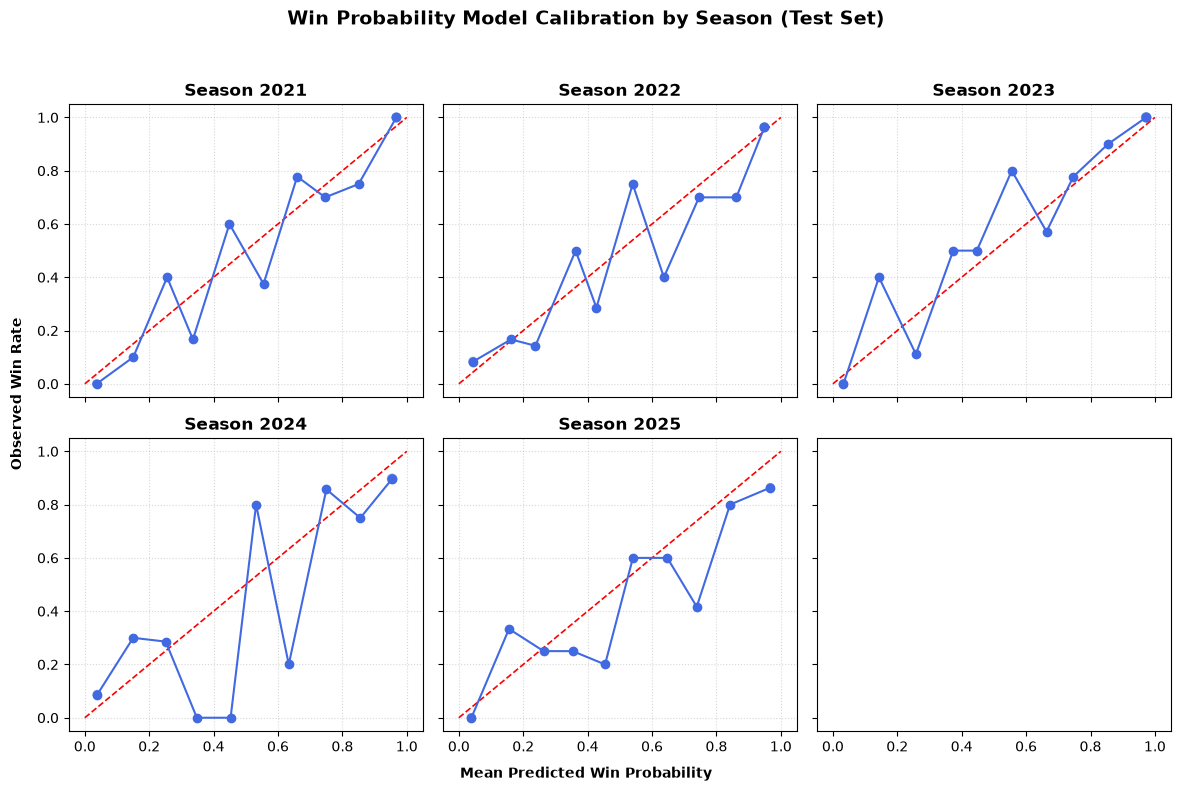

In [51]:
# Function for faceted season calibration plots
def plot_season_calibration(y_true, y_probs, seasons_series):
    df_cal = pd.DataFrame({"actual": y_true, "pred": y_probs, "season": seasons_series.values})
    df_cal["prob_bin"] = pd.cut(df_cal["pred"], bins=np.linspace(0, 1, 11), include_lowest=True)
    
    agg = df_cal.groupby(["season", "prob_bin"], observed=False).agg(
        mean_pred=("pred", "mean"),
        actual_win_rate=("actual", "mean"),
        game_count=("actual", "count")
    ).reset_index().dropna()

    unique_seasons = sorted(agg["season"].unique())
    fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for idx, s in enumerate(unique_seasons):
        ax = axes[idx]
        sub = agg[agg["season"] == s]
        ax.plot([0, 1], [0, 1], "r--", linewidth=1.2)
        ax.plot(sub["mean_pred"], sub["actual_win_rate"], "o-", color="royalblue", linewidth=1.5)
        ax.scatter(sub["mean_pred"], sub["actual_win_rate"], s=sub["game_count"] * 1.5, color="royalblue", alpha=0.7)
        ax.set_title(f"Season {s}", fontweight="bold")
        ax.grid(True, linestyle=":", alpha=0.5)

    plt.suptitle("Win Probability Model Calibration by Season (Test Set)", fontsize=14, fontweight="bold")
    fig.text(0.5, 0.02, "Mean Predicted Win Probability", ha="center", fontweight="bold")
    fig.text(0.02, 0.5, "Observed Win Rate", va="center", rotation="vertical", fontweight="bold")
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
    plt.show()

plot_season_calibration(y_test, pred_probs_diff, test_seasons)

Individual Team Features (No Differentials)

In [52]:
ind_predictors = [
    "is_home", "turnovers", "turnovers_allowed",
    "rushing_yards", "rushing_yards_allowed",
    "passing_yards", "passing_yards_allowed",
    "first_downs", "first_downs_allowed",
    "third_down_pct", "third_down_pct_opp",
    "pen_yds"
]

# Keep one row per game
nfl_ind = df.iloc[1::2].reset_index(drop=True)

nfl_ind = nfl_ind.dropna(
    subset=["win"] + ind_predictors
)

X_ind = nfl_ind[ind_predictors]
y_ind = nfl_ind["win"]
strata_ind = nfl_ind["season"]

X_train_ind, X_test_ind, y_train_ind, y_test_ind = train_test_split(
    X_ind,
    y_ind,
    test_size=0.20,
    random_state=2026,
    stratify=strata_ind
)

test_indices_ind = X_test_ind.index
test_seasons_ind = nfl_ind.loc[
    test_indices_ind, "season"
]

In [53]:
# Normalize features
scaler_ind = StandardScaler()

X_train_ind_scaled = pd.DataFrame(
    scaler_ind.fit_transform(X_train_ind),
    columns=ind_predictors,
    index=X_train_ind.index
)

X_test_ind_scaled = pd.DataFrame(
    scaler_ind.transform(X_test_ind),
    columns=ind_predictors,
    index=X_test_ind.index
)

X_train_ind_sm = sm.add_constant(X_train_ind_scaled)
X_test_ind_sm = sm.add_constant(X_test_ind_scaled)

logit_model_ind = sm.Logit(
    y_train_ind,
    X_train_ind_sm
).fit(
    method="lbfgs",
    maxiter=1000,
    disp=False
)

In [54]:
# Feature Importance
summary_ind_df = pd.DataFrame({
    "Predictor": logit_model_ind.params.index,
    "Std Beta": logit_model_ind.params.values,
    "Odds Ratio (1 SD)": np.exp(logit_model_ind.params.values),
    "z-statistic": logit_model_ind.tvalues.values,
    "p-value": logit_model_ind.pvalues.values
})
summary_ind_df = summary_ind_df[summary_ind_df["Predictor"] != "const"].copy()
summary_ind_df["Importance (|z|)"] = summary_ind_df["z-statistic"].abs()
summary_ind_df = summary_ind_df.sort_values(by="Importance (|z|)", ascending=False)

print(summary_ind_df.to_string(index=False))

            Predictor  Std Beta  Odds Ratio (1 SD)  z-statistic      p-value  Importance (|z|)
            turnovers -1.241460           0.288962   -11.024783 2.902189e-28         11.024783
    turnovers_allowed  1.125626           3.082145    10.758168 5.423782e-27         10.758168
       third_down_pct  0.654332           1.923857     5.945571 2.754947e-09          5.945571
rushing_yards_allowed -0.602550           0.547414    -4.662399 3.125438e-06          4.662399
   third_down_pct_opp -0.412347           0.662094    -3.907608 9.321450e-05          3.907608
        rushing_yards  0.469239           1.598778     3.575403 3.496888e-04          3.575403
passing_yards_allowed -0.493162           0.610692    -3.464856 5.305155e-04          3.464856
              pen_yds -0.277072           0.758000    -3.072882 2.120020e-03          3.072882
        passing_yards  0.375756           1.456092     2.582637 9.804854e-03          2.582637
          first_downs  0.324303           1.383066

C:\Users\jordy\AppData\Local\Temp\ipykernel_32300\932751226.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_ind_df, x="Importance (|z|)", y="Predictor", palette="mako")


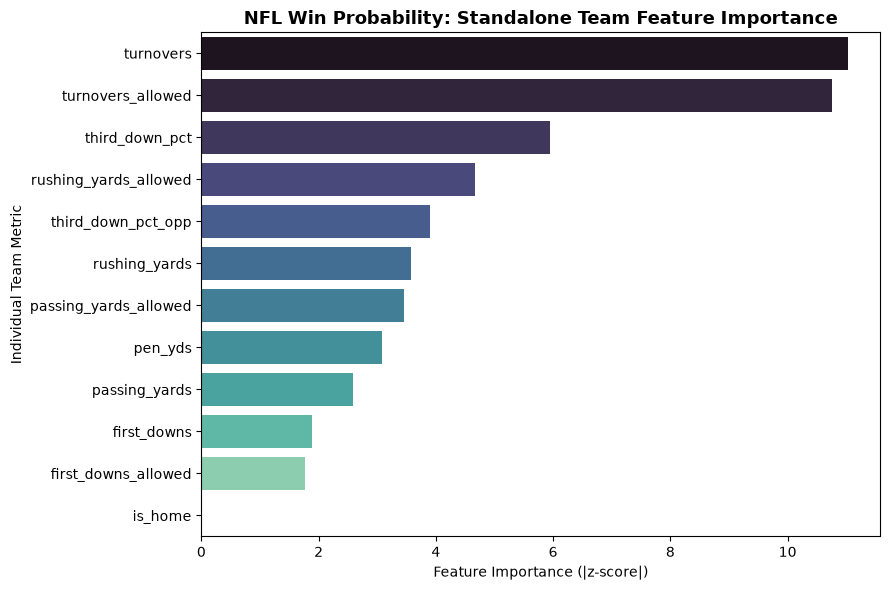

In [55]:
# Visualization
plt.figure(figsize=(9, 6))
sns.barplot(data=summary_ind_df, x="Importance (|z|)", y="Predictor", palette="mako")
plt.title("NFL Win Probability: Standalone Team Feature Importance", fontsize=13, fontweight="bold")
plt.xlabel("Feature Importance (|z-score|)")
plt.ylabel("Individual Team Metric")
plt.tight_layout()
plt.show()

In [56]:
# ---------------------------------------------------------
# Model 2: Out-of-Sample Evaluation & Calibration Plots (Individual Model)
# ---------------------------------------------------------

pred_probs_ind = logit_model_ind.predict(X_test_ind_sm)
pred_class_ind = (pred_probs_ind >= 0.5).astype(int)

metrics_ind = pd.DataFrame({
    "Metric": ["Accuracy", "ROC AUC", "Log Loss", "Brier Score"],
    "Test Score": [
        accuracy_score(y_test_ind, pred_class_ind),
        roc_auc_score(y_test_ind, pred_probs_ind),
        log_loss(y_test_ind, pred_probs_ind),
        brier_score_loss(y_test_ind, pred_probs_ind)
    ]
})

print("Out-of-Sample Performance (Individual Team Feature Model):")
print(metrics_ind.to_string(index=False))


Out-of-Sample Performance (Individual Team Feature Model):
     Metric  Test Score
   Accuracy    0.800738
    ROC AUC    0.895669
   Log Loss    0.404932
Brier Score    0.131290


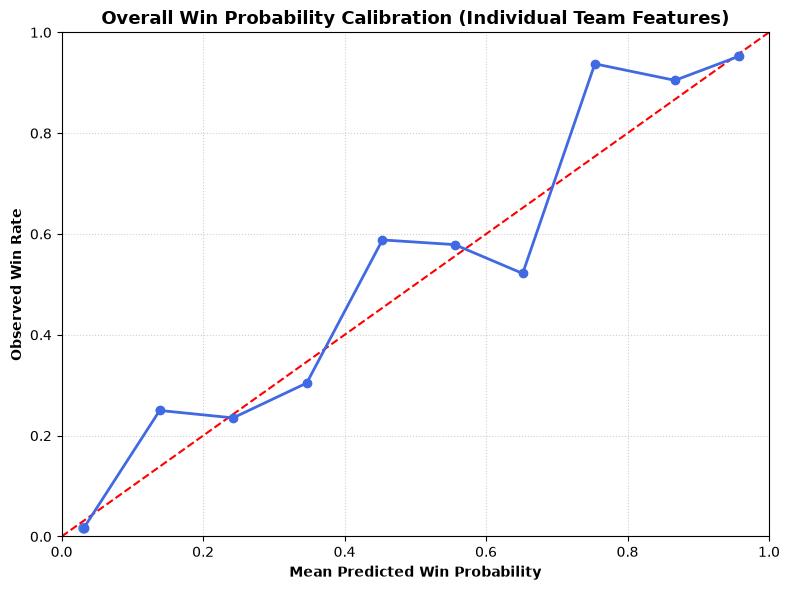

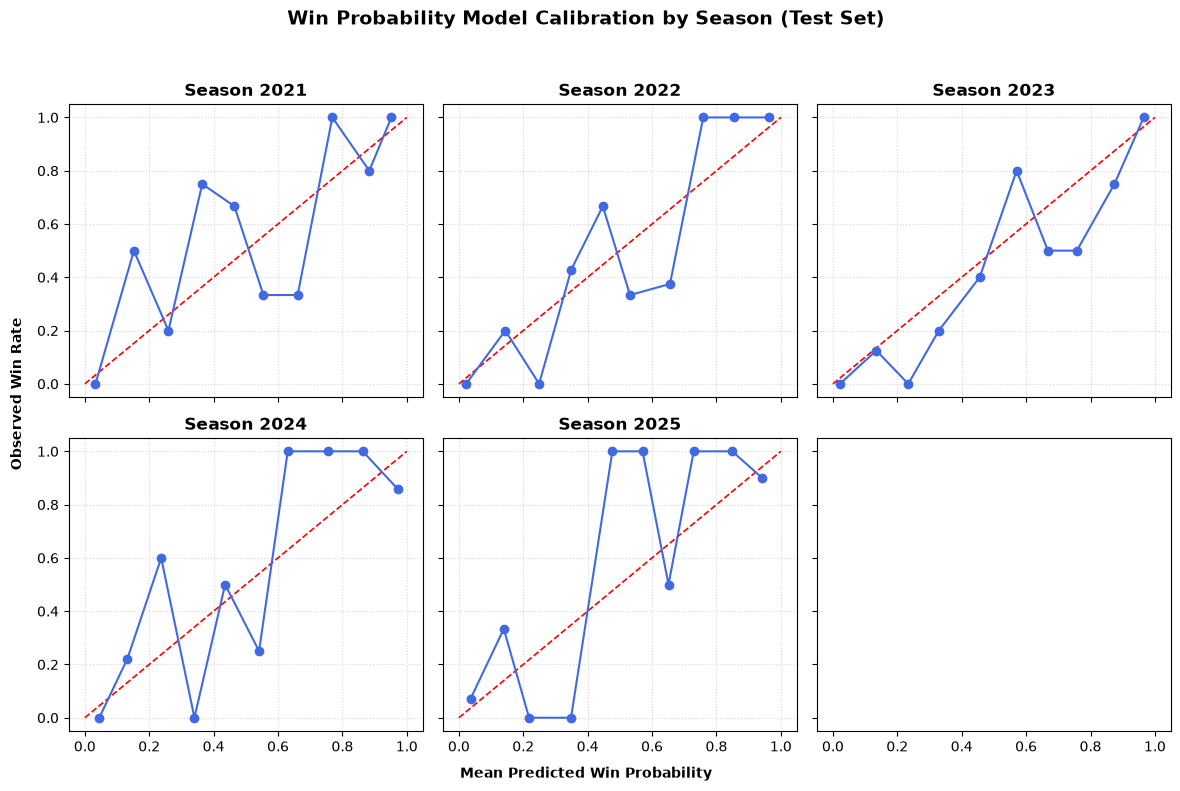

In [57]:
# Overall Calibration Plot
plot_overall_calibration(y_test_ind, pred_probs_ind, "(Individual Team Features)")

# Season Calibration Plots
plot_season_calibration(y_test_ind, pred_probs_ind, test_seasons_ind)

Compare multiple models and describe how they compare.  Clearly state which model is best and why.

Model 1: Game-Level Differentials
Out-of-Sample Performance (Differentials Model):
     Metric  Test Score
   Accuracy    0.815498
    ROC AUC    0.892049
   Log Loss    0.417320
Brier Score    0.134580
 
 Model 2: Out-of-Sample Evaluation & Calibration Plots (Individual Model)
 Out-of-Sample Performance (Individual Team Feature Model):
     Metric  Test Score
   Accuracy    0.800738
    ROC AUC    0.895669
   Log Loss    0.404932
Brier Score    0.131290

When comparing the two models, both performed well on the Out-of-Sample Performance test data. Model 1 had a higher accuracy of 81.55% compared with 80.07% for Model 2, giving Model 1 a slight advantage in correctly classifying wins and losses. However, Model 2 performed slightly better on the other evaluation metrics. With a higher ROC AUC (0.896 vs. 0.892), as well as a lower Log Loss (0.405 vs. 0.417) and lower Brier Score (0.131 vs. 0.135). These results suggest that Model 2 produced slightly better probability estimates, even though Model 1 had better overall classification accuracy.

Looking at the regression outputs, Model 1 had one predictor that stood out as having relatively high importance, while Model 2 had several predictors with more similar levels of importance. This suggests that Model 1 relies more heavily on certain differences between teams, whereas Model 2 spreads its predictive information across several individual team statistics.

Nonetheless, Model 1 is the better choice because it is more straightforward and has a relatively high accuracy score. Even though the other test scores favored Model 2, Model 1 uses statistical differentials to directly compare the two teams, making the model easier to interpret since the predictors represent how much one team outperformed or underperformed its opponent.
 